# E3 – Temperaturowa zależność oporu przewodników

Pomiar oporu trzech materiałów (Pt, Ni, C-grafit) w układzie mostka Wheatstone'a.  
Ponieważ R₁ = R₂ = 10,5 Ω, opór badanego opornika równa się odczytowi na opornicy dekadowej: **R_X = R_D**.  
Model liniowy: R(T) = R₀ + R₀ · α · (T − T₀), gdzie T₀ = 20 °C.  
Współczynnik temperaturowy wyznaczany z regresji liniowej: **α = a / R₀**, gdzie *a* to nachylenie prostej.

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.dpi': 150,
})

# Paleta kolorów z Astorii
COLORS    = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
C_DATA    = '#37474F'   # punkty pomiarowe w wykresach regresji
C_FIT     = '#e53935'   # prosta regresji

# Pt → COLORS[0], Ni → COLORS[1], C-grafit → COLORS[2]
MAT_COLOR = {'Pt': COLORS[0], 'Ni': COLORS[1], 'C': COLORS[2]}


def format_val_unc(val, unc, n=2):
    """Formatuje wartość ± niepewność z zaokrągleniem do n cyfr znaczących niepewności."""
    if not np.isfinite(unc) or not np.isfinite(val) or unc == 0:
        return f"{val:.4g}", f"{unc:.4g}"
    d = int(np.floor(np.log10(abs(unc)))) - (n - 1)
    unc_r = round(unc, -d)
    val_r = round(val, -d)
    if d <= 0:
        fmt = f".{-d}f"
        return f"{val_r:{fmt}}", f"{unc_r:{fmt}}"
    else:
        return f"{val_r:.0f}", f"{unc_r:.0f}"

## 1. Wczytanie danych

In [76]:
# Stałe układu pomiarowego
R1 = 10.5   # Ω
R2 = 10.5   # Ω  → R_X = (R1/R2) * R_D = R_D
T0 = 22.0   # °C – temperatura odniesienia

# Wartości tablicowe współczynników temperaturowych [1/K]
alpha_lit = {'Pt': 0.0039, 'Ni': 0.006, 'C': -0.0005}

materials = {
    'Pt': {'label': 'Platyna (Pt)', 'heating_file': 'pt_heating.csv', 'cooling_file': 'pt_cooling.csv'},
    'Ni': {'label': 'Nikiel (Ni)', 'heating_file': 'ni_heating.csv', 'cooling_file': 'ni_cooling.csv'},
    'C':  {'label': 'Grafit (C)',  'heating_file': 'c_heating.csv',  'cooling_file': 'c_cooling.csv'},
}
mat_list = list(materials.keys())   # ['Pt', 'Ni', 'C']

data = {}
for mat, info in materials.items():
    dh = pd.read_csv(info['heating_file'])
    dc = pd.read_csv(info['cooling_file'])
    data[mat] = {'heating': dh, 'cooling': dc}
    print(f"{info['label']}: ogrzewanie {len(dh)} pkt, chłodzenie {len(dc)} pkt")

Platyna (Pt): ogrzewanie 25 pkt, chłodzenie 22 pkt
Nikiel (Ni): ogrzewanie 25 pkt, chłodzenie 22 pkt
Grafit (C): ogrzewanie 26 pkt, chłodzenie 22 pkt


## 2. Wykresy surowych danych z niepewnościami

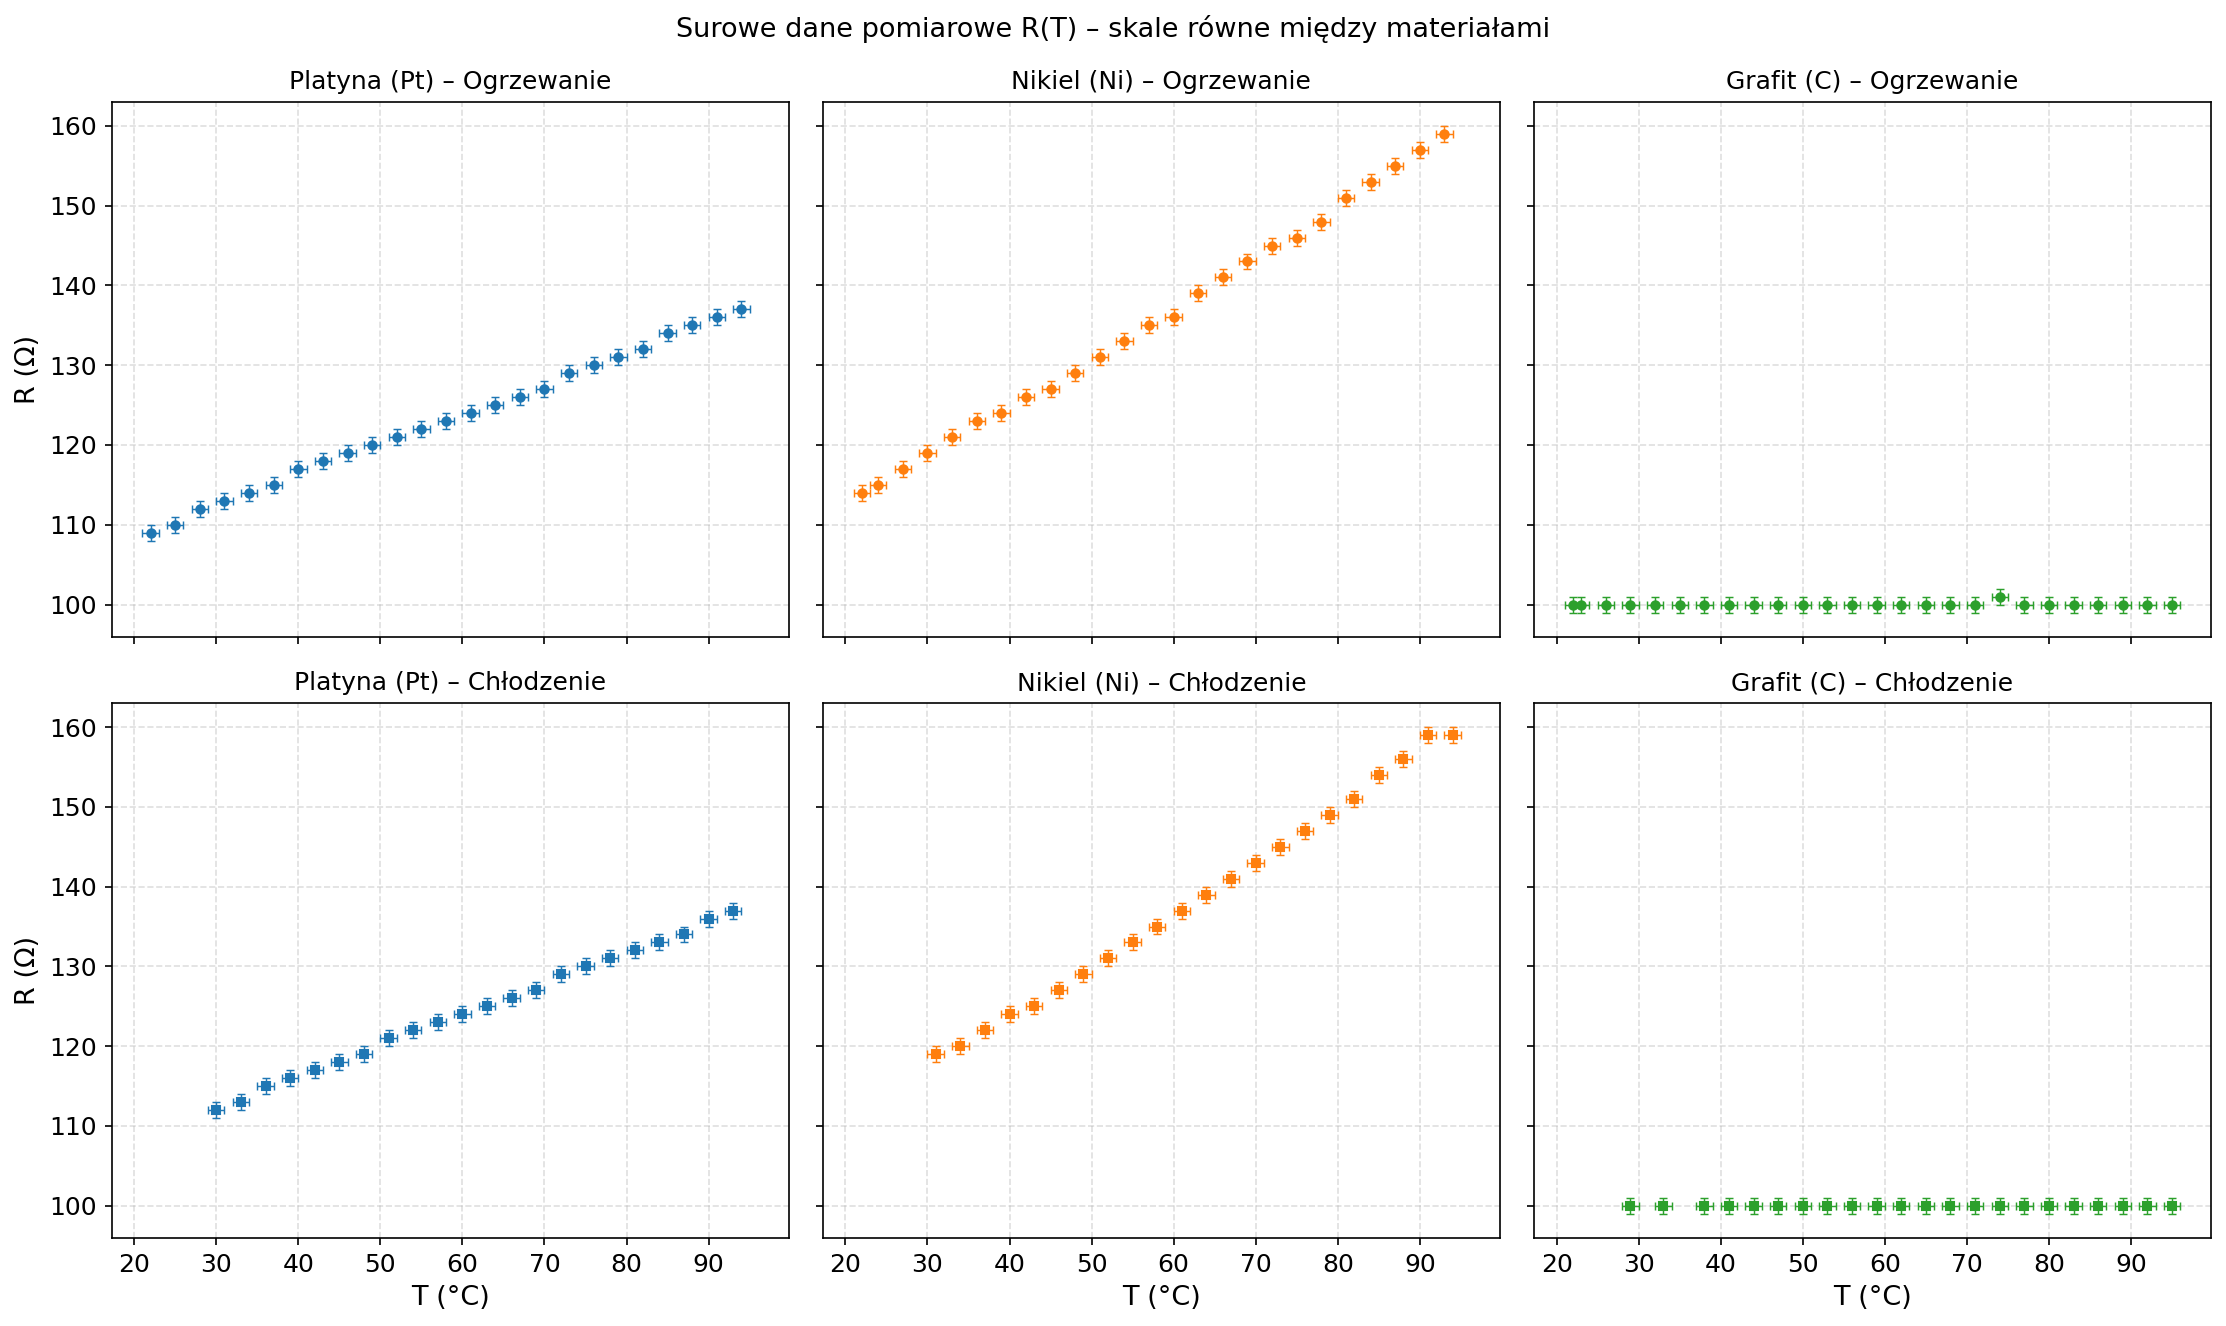

In [77]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)

for col, mat in enumerate(mat_list):
    dh = data[mat]['heating']
    dc = data[mat]['cooling']
    c  = MAT_COLOR[mat]

    for row, (df, phase_label, marker) in enumerate([
        (dh, 'Ogrzewanie', 'o'),
        (dc, 'Chłodzenie', 's'),
    ]):
        ax = axes[row, col]
        ax.errorbar(
            df['T'], df['R'], xerr=df['u_T'], yerr=df['u_R'],
            fmt=marker, color=c, markersize=4, capsize=2,
            elinewidth=0.7, capthick=0.7,
        )
        ax.set_title(f"{materials[mat]['label']} – {phase_label}", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.4)
        if row == 1:
            ax.set_xlabel('T (°C)')
        if col == 0:
            ax.set_ylabel('R (Ω)')

fig.suptitle("Surowe dane pomiarowe R(T) – skale równe między materiałami", fontsize=13)
plt.tight_layout()
plt.show()
fig.savefig('wykres1_surowe_dane.pdf', format='pdf', bbox_inches='tight')
plt.close(fig)

## 3. Regresja liniowa R(T) = a·T + b

Używamy ważonej metody najmniejszych kwadratów (`scipy.curve_fit` z `sigma=u_R`, `absolute_sigma=True`).  
Macierz kowariancji `pcov` daje niepewności współczynników oraz ich korelację.  

**Pasmo niepewności regresji** w punkcie T:  
$$u_{\hat{R}}(T) = \sqrt{T^2 \cdot \sigma_a^2 + \sigma_b^2 + 2T \cdot \mathrm{cov}(a,b)}$$

**Wyznaczenie α:**  
Z dopasowania: nachylenie $a = R_0 \cdot \alpha$, więc $\alpha = a / R_0$, gdzie $R_0 = a \cdot T_0 + b$.  
Propagacja niepewności (z uwzględnieniem korelacji a i b):  
$$u_\alpha = \sqrt{\left(\frac{b}{R_0^2}\right)^2 \sigma_a^2 + \left(\frac{a}{R_0^2}\right)^2 \sigma_b^2 - 2\frac{ab}{R_0^4}\,\mathrm{cov}(a,b)}$$

In [78]:
def linear_model(T, a, b):
    return a * T + b


def fit_phase(mat, phase):
    """Dopasowanie dla pojedynczej fazy ('heating' lub 'cooling') lub 'combined'."""
    if phase == 'combined':
        dh = data[mat]['heating']
        dc = data[mat]['cooling']
        T_arr   = np.concatenate([dh['T'].values,   dc['T'].values],   dtype=float)
        R_arr   = np.concatenate([dh['R'].values,   dc['R'].values],   dtype=float)
        u_R_arr = np.concatenate([dh['u_R'].values, dc['u_R'].values], dtype=float)
    else:
        df      = data[mat][phase]
        T_arr   = df['T'].values.astype(float)
        R_arr   = df['R'].values.astype(float)
        u_R_arr = df['u_R'].values.astype(float)

    popt, pcov = curve_fit(linear_model, T_arr, R_arr,
                           sigma=u_R_arr, absolute_sigma=True)
    a, b   = popt
    sa     = np.sqrt(pcov[0, 0])
    sb     = np.sqrt(pcov[1, 1])
    cov_ab = pcov[0, 1]

    R0   = a * T0 + b
    u_R0 = np.sqrt((T0 * sa)**2 + sb**2 + 2 * T0 * cov_ab)

    alpha   = a / R0
    d_da    = b / R0**2
    d_db    = -a / R0**2
    u_alpha = np.sqrt(d_da**2 * sa**2 + d_db**2 * sb**2 + 2 * d_da * d_db * cov_ab)

    w      = 1.0 / u_R_arr**2
    SS_res = np.sum(w * (R_arr - linear_model(T_arr, *popt))**2)
    SS_tot = np.sum(w * (R_arr - np.average(R_arr, weights=w))**2)
    r2     = 1.0 - SS_res / SS_tot

    return dict(a=a, b=b, sa=sa, sb=sb, cov_ab=cov_ab, pcov=pcov,
                R0=R0, u_R0=u_R0, alpha=alpha, u_alpha=u_alpha,
                T_all=T_arr, R_all=R_arr, u_R_all=u_R_arr, r2=r2)


# Trzy zestawy wyników
results_h   = {mat: fit_phase(mat, 'heating')  for mat in mat_list}
results_c   = {mat: fit_phase(mat, 'cooling')  for mat in mat_list}
results_all = {mat: fit_phase(mat, 'combined') for mat in mat_list}
# zachowaj też jako 'results' dla kompatybilności z komórką wyników
results = results_all

for phase_label, res_dict in [('Ogrzewanie', results_h),
                               ('Chłodzenie', results_c),
                               ('Łączone',    results_all)]:
    print(f"\n{'─'*70}")
    print(f"  {phase_label}")
    print(f"{'─'*70}")
    for mat in mat_list:
        r = res_dict[mat]
        print(f"  {materials[mat]['label']:15s}  "
              f"a=({r['a']:.4f}±{r['sa']:.4f}) Ω/°C  "
              f"b=({r['b']:.2f}±{r['sb']:.2f}) Ω  "
              f"R²={r['r2']:.5f}")


──────────────────────────────────────────────────────────────────────
  Ogrzewanie
──────────────────────────────────────────────────────────────────────
  Platyna (Pt)     a=(0.3821±0.0092) Ω/°C  b=(101.00±0.57) Ω  R²=0.99790
  Nikiel (Ni)      a=(0.6299±0.0093) Ω/°C  b=(99.55±0.57) Ω  R²=0.99792
  Grafit (C)       a=(0.0013±0.0088) Ω/°C  b=(99.97±0.54) Ω  R²=0.02155

──────────────────────────────────────────────────────────────────────
  Chłodzenie
──────────────────────────────────────────────────────────────────────
  Platyna (Pt)     a=(0.3892±0.0112) Ω/°C  b=(100.61±0.72) Ω  R²=0.99830
  Nikiel (Ni)      a=(0.6623±0.0112) Ω/°C  b=(97.01±0.73) Ω  R²=0.99738
  Grafit (C)       a=(0.0000±inf) Ω/°C  b=(100.00±inf) Ω  R²=-inf

──────────────────────────────────────────────────────────────────────
  Łączone
──────────────────────────────────────────────────────────────────────
  Platyna (Pt)     a=(0.3850±0.0071) Ω/°C  b=(100.85±0.45) Ω  R²=0.99799
  Nikiel (Ni)      a=(0.6412±0.007

/var/folders/rf/r1ckh7bd7hjfcr3c3b8j80840000gn/T/ipykernel_2416/2255119135.py:19: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(linear_model, T_arr, R_arr,
/var/folders/rf/r1ckh7bd7hjfcr3c3b8j80840000gn/T/ipykernel_2416/2255119135.py:32: RuntimeWarning: invalid value encountered in scalar add
  u_alpha = np.sqrt(d_da**2 * sa**2 + d_db**2 * sb**2 + 2 * d_da * d_db * cov_ab)
/var/folders/rf/r1ckh7bd7hjfcr3c3b8j80840000gn/T/ipykernel_2416/2255119135.py:37: RuntimeWarning: divide by zero encountered in scalar divide
  r2     = 1.0 - SS_res / SS_tot


## 4. Wykresy z regresjami liniowymi i pasmem niepewności

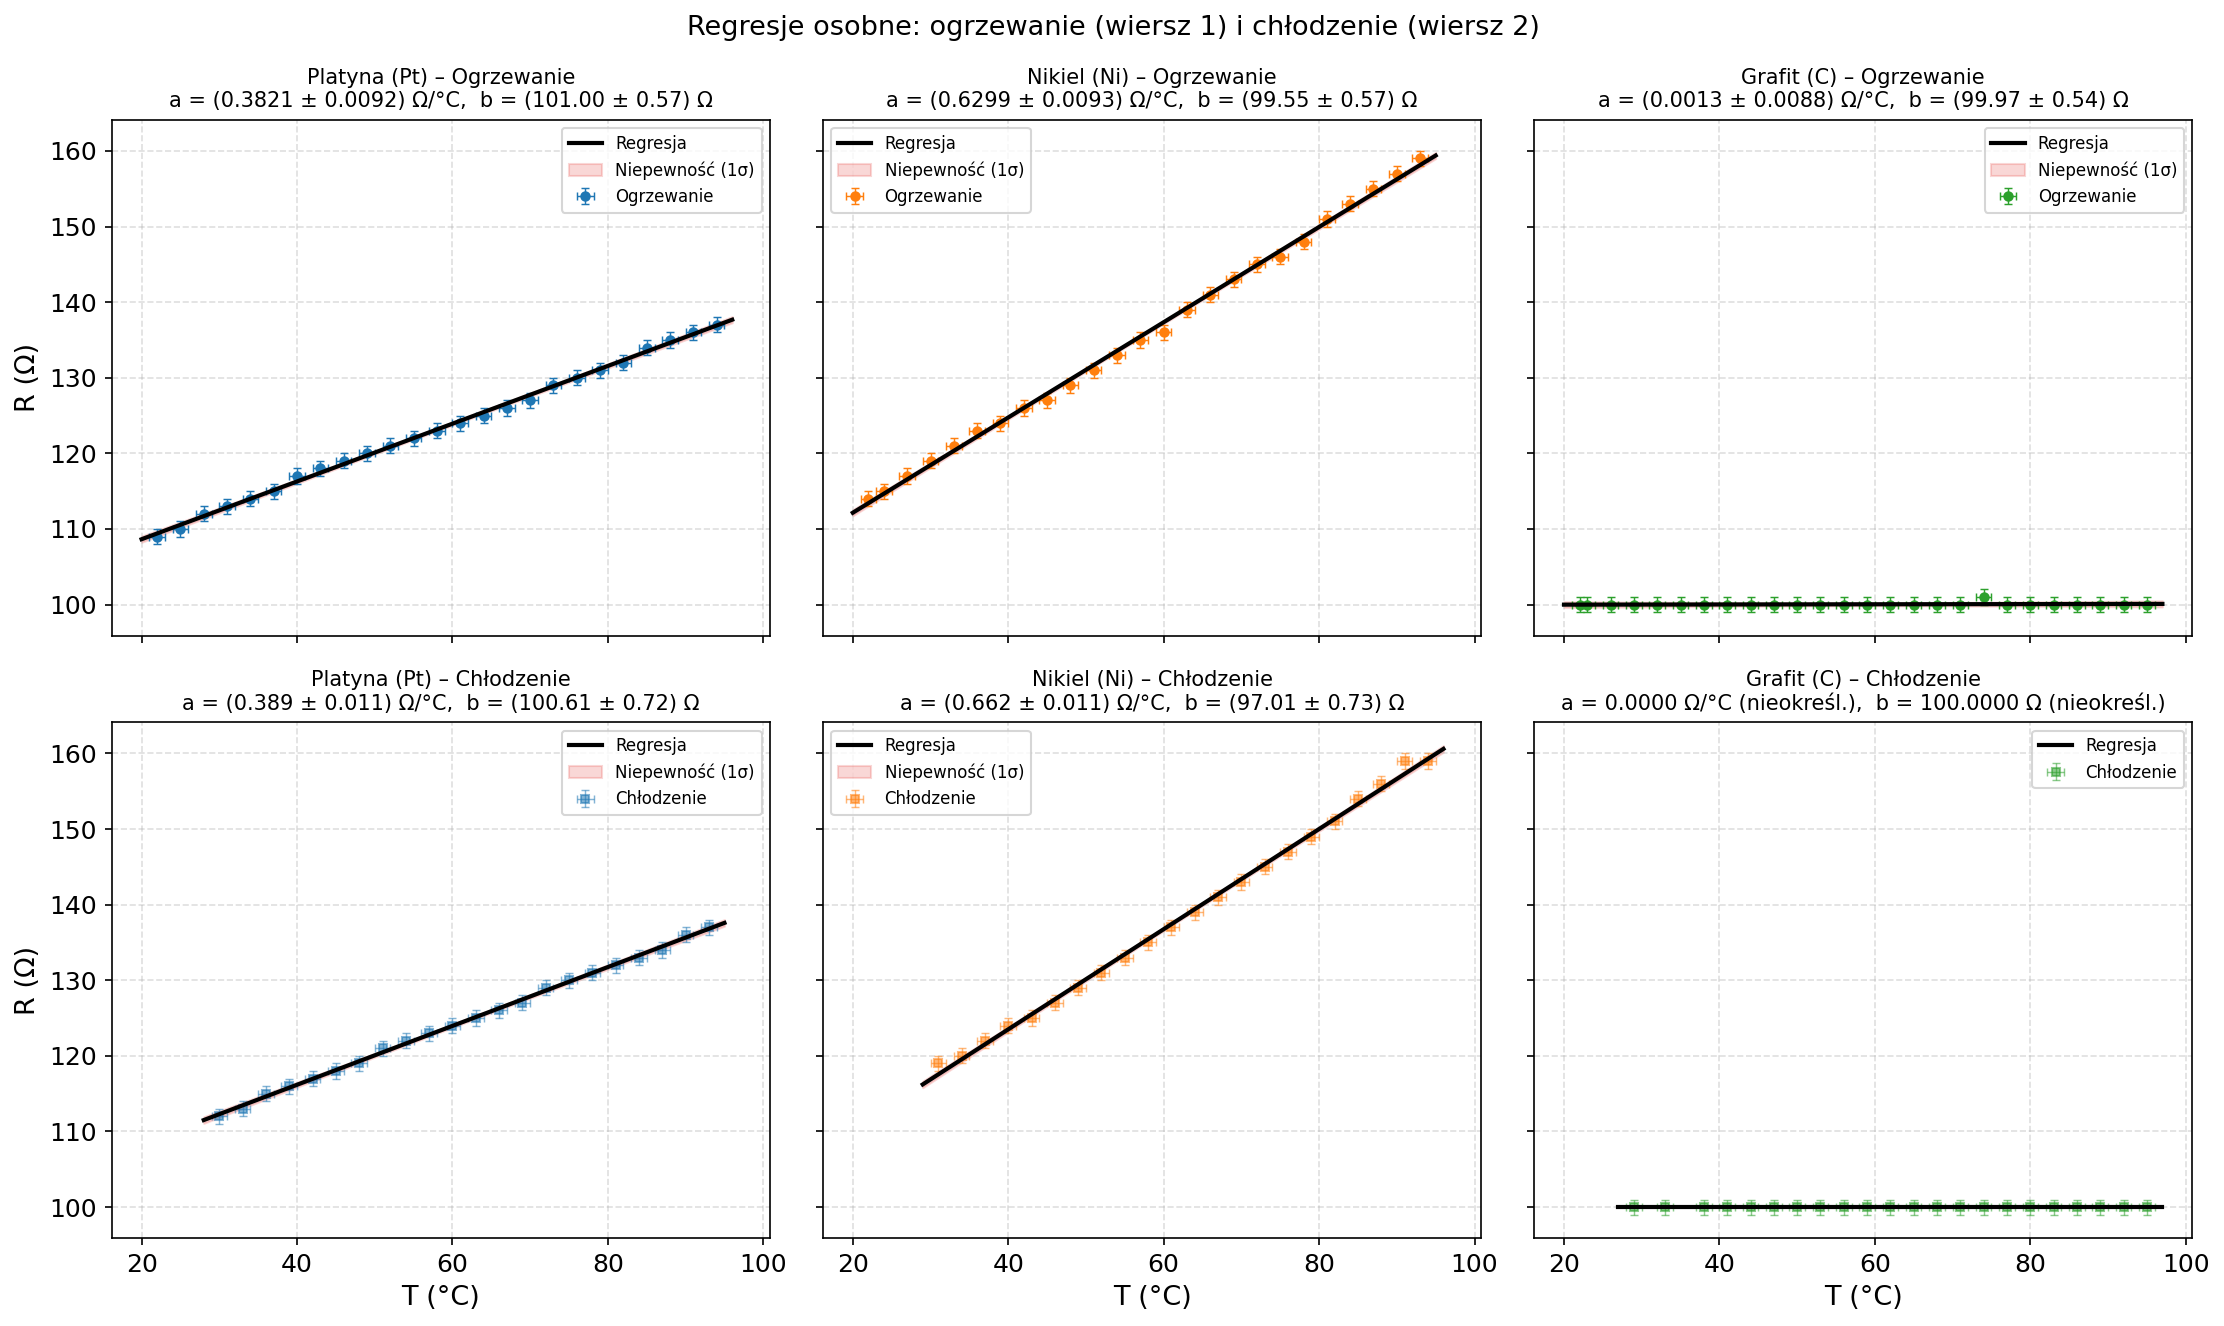

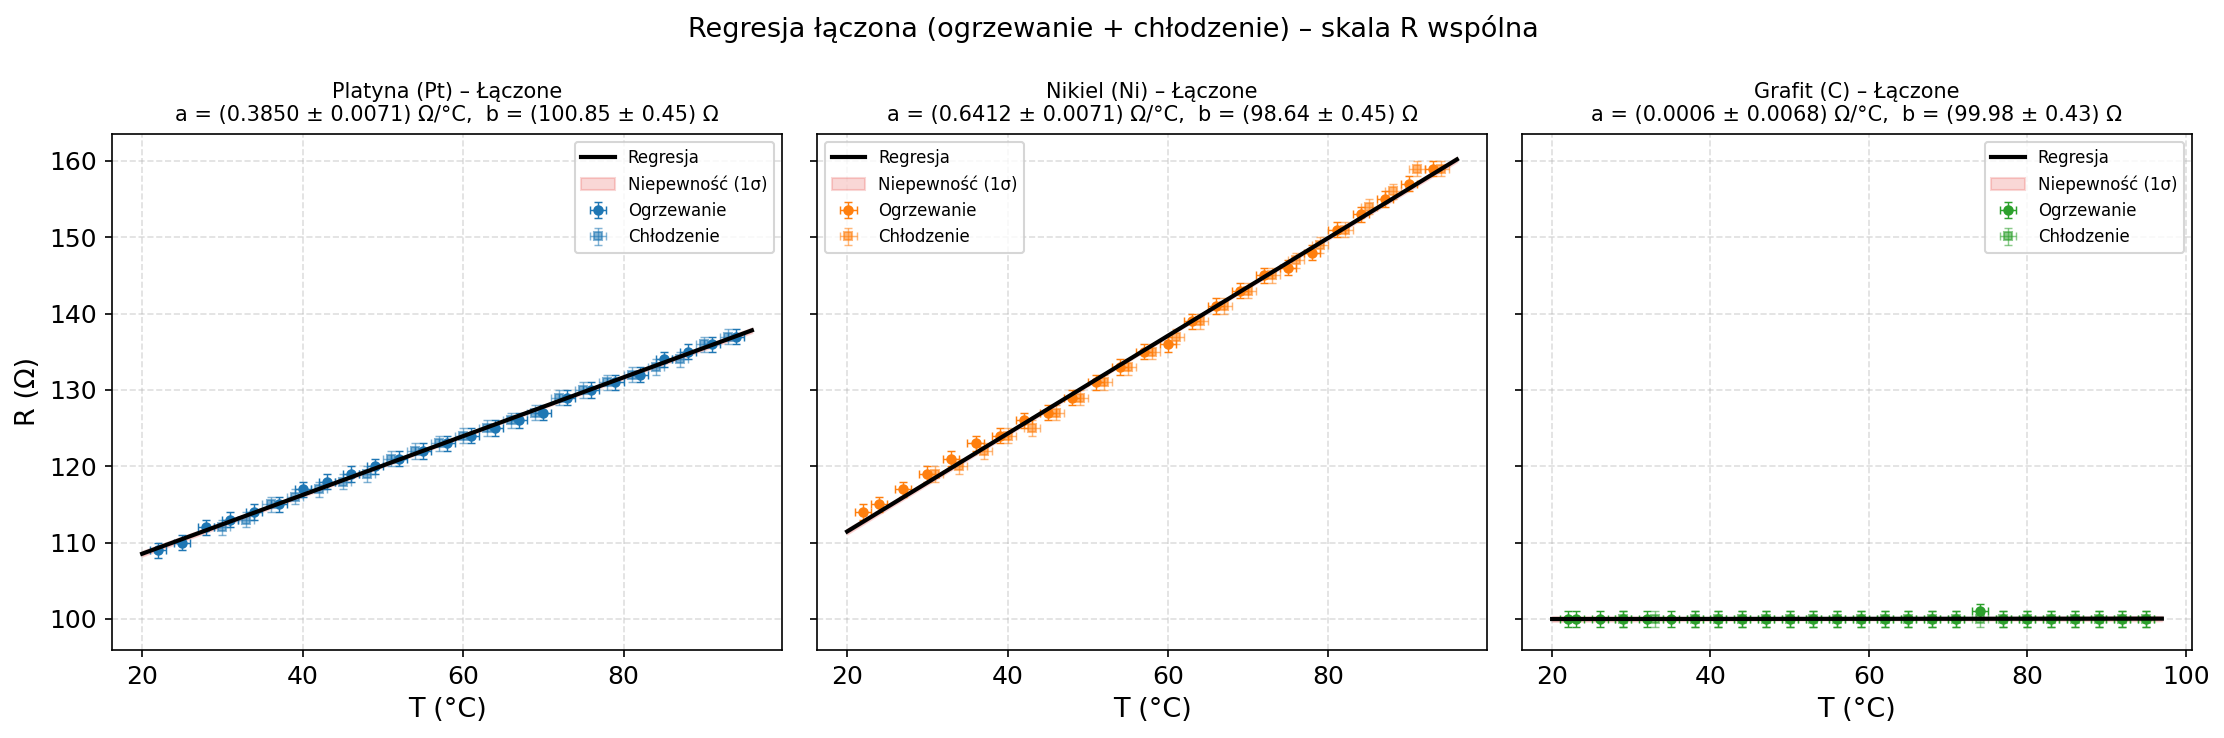

Zapisano: wykres2_regresja_osobne.pdf, wykres3_regresja_laczona.pdf


In [79]:
def plot_regression_band(ax, res, color, data_heating=None, data_cooling=None,
                          show_heating=True, show_cooling=True):
    """Rysuje punkty w kolorze materiału i regresję (C_FIT) z pasmem niepewności."""
    if show_heating and data_heating is not None:
        dh = data_heating
        ax.errorbar(dh['T'], dh['R'], xerr=dh['u_T'], yerr=dh['u_R'],
                    fmt='o', color=color, markersize=4, capsize=2,
                    elinewidth=0.7, capthick=0.7, label='Ogrzewanie', zorder=5)
    if show_cooling and data_cooling is not None:
        dc = data_cooling
        ax.errorbar(dc['T'], dc['R'], xerr=dc['u_T'], yerr=dc['u_R'],
                    fmt='s', color=color, markersize=4, capsize=2,
                    elinewidth=0.7, capthick=0.7, alpha=0.55,
                    label='Chłodzenie', zorder=4)

    T_fit = np.linspace(res['T_all'].min() - 2, res['T_all'].max() + 2, 400)
    R_fit = linear_model(T_fit, res['a'], res['b'])
    ax.plot(T_fit, R_fit, color='black', linewidth=2.0, label='Regresja', zorder=6)

    pcov    = res['pcov']
    var_fit = pcov[0,0]*T_fit**2 + pcov[1,1] + 2*T_fit*pcov[0,1]
    if np.all(np.isfinite(var_fit)) and np.all(var_fit >= 0):
        u_fit = np.sqrt(var_fit)
        ax.fill_between(T_fit, R_fit - u_fit, R_fit + u_fit,
                        color=C_FIT, alpha=0.2, label='Niepewność (1σ)')


def reg_title(mat_label, phase_label, res):
    """Tytuł z współczynnikami regresji a i b; obsługuje nieskończone niepewności."""
    def fmt(val, unc, unit):
        if np.isfinite(unc):
            v, u = format_val_unc(val, unc)
            return f"({v} \u00b1 {u}) {unit}"
        else:
            return f"{val:.4f} {unit} (nieokreśl.)"
    a_str = fmt(res['a'], res['sa'], "Ω/°C")
    b_str = fmt(res['b'], res['sb'], "Ω")
    return f"{mat_label} – {phase_label}\na = {a_str},  b = {b_str}"


# ── Wykres 2: regresje osobne, siatka 2×3 ─────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)

phase_configs = [
    (results_h, 'Ogrzewanie', True,  False),
    (results_c, 'Chłodzenie', False, True),
]

for row, (res_dict, phase_label, sh, sc) in enumerate(phase_configs):
    for col, mat in enumerate(mat_list):
        ax  = axes[row, col]
        res = res_dict[mat]

        plot_regression_band(
            ax, res, MAT_COLOR[mat],
            data_heating=data[mat]['heating'],
            data_cooling=data[mat]['cooling'],
            show_heating=sh, show_cooling=sc,
        )
        ax.set_title(reg_title(materials[mat]['label'], phase_label, res),
                     fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(fontsize=8)
        if row == 1:
            ax.set_xlabel('T (°C)')
        if col == 0:
            ax.set_ylabel('R (Ω)')

fig.suptitle('Regresje osobne: ogrzewanie (wiersz 1) i chłodzenie (wiersz 2)',
             fontsize=13)
plt.tight_layout()
plt.show()
fig.savefig('wykres2_regresja_osobne.pdf', format='pdf', bbox_inches='tight')
plt.close(fig)


# ── Wykres 3: regresja łączona, siatka 1×3 ────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for col, mat in enumerate(mat_list):
    ax  = axes[col]
    res = results_all[mat]

    plot_regression_band(
        ax, res, MAT_COLOR[mat],
        data_heating=data[mat]['heating'],
        data_cooling=data[mat]['cooling'],
        show_heating=True, show_cooling=True,
    )
    ax.set_title(reg_title(materials[mat]['label'], 'Łączone', res),
                 fontsize=10)
    ax.set_xlabel('T (°C)')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=8)
    if col == 0:
        ax.set_ylabel('R (Ω)')

fig.suptitle('Regresja łączona (ogrzewanie + chłodzenie) – skala R wspólna',
             fontsize=13)
plt.tight_layout()
plt.show()
fig.savefig('wykres3_regresja_laczona.pdf', format='pdf', bbox_inches='tight')
plt.close(fig)

print('Zapisano: wykres2_regresja_osobne.pdf, wykres3_regresja_laczona.pdf')

## 5. Wyznaczone współczynniki temperaturowe α

In [80]:
print(f"Temperatura odniesienia T₀ = {T0} °C\n")

phase_sets = [
    ('Ogrzewanie', results_h),
    ('Chłodzenie', results_c),
    ('Łączone',    results_all),
]

# ── Tabela współczynników regresji ────────────────────────────────────────────
print(f"{'Faza':<12} {'Materiał':<15} {'a [Ω/°C]':>12} {'u(a)':>9} "
      f"{'b [Ω]':>9} {'u(b)':>7}  {'R₀ [Ω]':>9} {'u(R₀)':>7}")
print("─" * 90)
for phase_label, res_dict in phase_sets:
    for mat in mat_list:
        r = res_dict[mat]
        print(f"{phase_label:<12} {materials[mat]['label']:<15} "
              f"{r['a']:>12.5f} {r['sa']:>9.5f} "
              f"{r['b']:>9.3f} {r['sb']:>7.3f}  "
              f"{r['R0']:>9.4f} {r['u_R0']:>7.4f}")
    print()

# ── Tabela α z porównaniem z literaturą ───────────────────────────────────────
print(f"\n{'Faza':<12} {'Materiał':<15} {'α [10⁻³/K]':>13} {'u(α)':>9} "
      f"{'α_lit':>9} {'|Δ|/u':>8}")
print("─" * 75)
for phase_label, res_dict in phase_sets:
    for mat in mat_list:
        r     = res_dict[mat]
        a_exp = r['alpha'] * 1e3
        u_a   = r['u_alpha'] * 1e3
        a_l   = alpha_lit[mat] * 1e3
        nsig  = abs(a_exp - a_l) / u_a
        print(f"{phase_label:<12} {materials[mat]['label']:<15} "
              f"{a_exp:>13.4f} {u_a:>9.4f} {a_l:>9.4f} {nsig:>7.1f}σ")
    print()

Temperatura odniesienia T₀ = 22.0 °C

Faza         Materiał            a [Ω/°C]      u(a)     b [Ω]    u(b)     R₀ [Ω]   u(R₀)
──────────────────────────────────────────────────────────────────────────────────────────
Ogrzewanie   Platyna (Pt)         0.38205   0.00925   101.001   0.572   109.4062  0.3883
Ogrzewanie   Nikiel (Ni)          0.62994   0.00927    99.548   0.565   113.4070  0.3816
Ogrzewanie   Grafit (C)           0.00126   0.00877    99.966   0.541    99.9936  0.3684

Chłodzenie   Platyna (Pt)         0.38923   0.01120   100.608   0.721   109.1707  0.4912
Chłodzenie   Nikiel (Ni)          0.66234   0.01120    97.013   0.732   111.5844  0.5013
Chłodzenie   Grafit (C)           0.00000       inf   100.000     inf   100.0000     inf

Łączone      Platyna (Pt)         0.38504   0.00710   100.845   0.448   109.3163  0.3046
Łączone      Nikiel (Ni)          0.64125   0.00708    98.635   0.446   112.7429  0.3035
Łączone      Grafit (C)           0.00064   0.00679    99.983   0.43

## 6. Wyznaczenie α z dwóch skrajnych punktów pomiarowych

Zgodnie z zaleceniami skryptu, wyznaczamy temperaturowy współczynnik oporu właściwego $\alpha$ z dwóch skrajnych pomiarów. Dla ujednolicenia wybieramy z fazy pierwszej (ogrzewanie) pierwszy pomiar (temperatura pokojowa $T_1$) i ostatni pomiar (temperatura blisko wrzenia wody $T_2$).

Zależność: $R_i = R_0 [1 + \alpha(T_i - T_0)]$, $i=1,2$.
Z tego wyliczamy $a = \frac{R_2 - R_1}{T_2 - T_1}$.
Następnie wyznaczamy opór w temperaturze odniesienia $T_0$: $R_0 = R_1 - a(T_1 - T_0)$ i na końcu współczynnik:
$$\alpha = \frac{a}{R_0}$$
Wyznaczamy też niepewności $u_a$, $u_{R_0}$ oraz $u_\alpha$ z prawa przenoszenia błędów z pełnych pochodnych.

In [81]:
def calc_2point_alpha(R1, u_R1, R2, u_R2, T1, u_T1, T2, u_T2, T0):
    a = (R2 - R1) / (T2 - T1)
    R0 = R1 - a * (T1 - T0)
    alpha = a / R0
    
    # Numeryczne wyznaczenie pochodnych (prostsze i odporne na błędy wzorów analitycznych)
    eps = 1e-6
    d_R1 = ( ( (R2 - (R1+eps))/(T2 - T1) ) / ((R1+eps) - (R2 - (R1+eps))/(T2 - T1)*(T1-T0)) - alpha ) / eps
    d_R2 = ( ( ((R2+eps) - R1)/(T2 - T1) ) / (R1 - ((R2+eps) - R1)/(T2 - T1)*(T1-T0)) - alpha ) / eps
    d_T1 = ( ( (R2 - R1)/(T2 - (T1+eps)) ) / (R1 - (R2 - R1)/(T2 - (T1+eps))*((T1+eps)-T0)) - alpha ) / eps
    d_T2 = ( ( (R2 - R1)/((T2+eps) - T1) ) / (R1 - (R2 - R1)/((T2+eps) - T1)*(T1-T0)) - alpha ) / eps
    
    u_alpha = np.sqrt( (d_R1 * u_R1)**2 + (d_R2 * u_R2)**2 + (d_T1 * u_T1)**2 + (d_T2 * u_T2)**2 )
    
    return a, R0, alpha, u_alpha

results_2pt = {}

print("Analiza dwóch skrajnych punktów (temperatura pokojowa vs. zbliżona do wrzenia):\n")
print(f"{'Materiał':<12} {'T_1 [°C]':>8} {'R_1 [Ω]':>8} {'T_2 [°C]':>8} {'R_2 [Ω]':>8} {'α [10⁻³/K]':>13} {'u(α)':>8} {'|Δ|/u':>8}")
print("-" * 85)

for mat in mat_list:
    df = data[mat]['heating']
    # Punkty: pierwszy (pokojowa) i ostatni (najgorętszy)
    pt1 = df.iloc[0]
    pt2 = df.iloc[-1]
    
    T1, u_T1, R1, u_R1 = pt1['T'], pt1['u_T'], pt1['R'], pt1['u_R']
    T2, u_T2, R2, u_R2 = pt2['T'], pt2['u_T'], pt2['R'], pt2['u_R']
    
    a, R0, num_a, num_ua = calc_2point_alpha(R1, u_R1, R2, u_R2, T1, u_T1, T2, u_T2, T0)
    
    results_2pt[mat] = {
        'T1': T1, 'R1': R1, 'T2': T2, 'R2': R2,
        'alpha': num_a, 'u_alpha': num_ua, 'a': a, 'R0': R0
    }
    
    a_exp = num_a * 1e3
    u_a   = num_ua * 1e3
    a_l   = alpha_lit[mat] * 1e3
    nsig  = abs(a_exp - a_l) / u_a
    
    print(f"{materials[mat]['label']:<12} {T1:>8.1f} {R1:>8.1f} {T2:>8.1f} {R2:>8.1f} "
          f"{a_exp:>13.4f} {u_a:>8.4f} {nsig:>7.1f}σ")

Analiza dwóch skrajnych punktów (temperatura pokojowa vs. zbliżona do wrzenia):

Materiał     T_1 [°C]  R_1 [Ω] T_2 [°C]  R_2 [Ω]    α [10⁻³/K]     u(α)    |Δ|/u
-------------------------------------------------------------------------------------
Platyna (Pt)     22.0    109.0     94.0    137.0        3.5678   0.2196     1.5σ
Nikiel (Ni)      22.0    114.0     93.0    159.0        5.5597   0.2510     1.8σ
Grafit (C)       22.0    100.0     95.0    100.0        0.0000   0.1937     2.6σ


In [82]:
print("Porównanie metod wyznaczania α (regresja łączona vs. metoda 2 punktów):\n")
print(f"{'Materiał':<15} {'α (regresja) [10⁻³/K]':>22} {'α (2 pkt) [10⁻³/K]':>21} {'Różnica':>11}")
print("-" * 75)

for mat in mat_list:
    a_reg = results_all[mat]['alpha'] * 1e3
    u_a_reg = results_all[mat]['u_alpha'] * 1e3
    
    a_2pt = results_2pt[mat]['alpha'] * 1e3
    u_a_2pt = results_2pt[mat]['u_alpha'] * 1e3
    
    diff = abs(a_reg - a_2pt)
    u_diff = np.sqrt(u_a_reg**2 + u_a_2pt**2) # Oczywiście są skorelowane ze względu na dane, ale dla wygody szacujemy sumą kwadratów
    nsig = diff / u_diff
    
    # formatowanie do wypisu
    print(f"{materials[mat]['label']:<15} "
          f"{a_reg:>9.4f} ± {u_a_reg:<8.4f} "
          f"{a_2pt:>9.4f} ± {u_a_2pt:<8.4f} "
          f"{nsig:>5.1f}σ")

Porównanie metod wyznaczania α (regresja łączona vs. metoda 2 punktów):

Materiał         α (regresja) [10⁻³/K]    α (2 pkt) [10⁻³/K]     Różnica
---------------------------------------------------------------------------
Platyna (Pt)       3.5223 ± 0.0738      3.5678 ± 0.2196     0.2σ
Nikiel (Ni)        5.6877 ± 0.0766      5.5597 ± 0.2510     0.5σ
Grafit (C)         0.0064 ± 0.0679      0.0000 ± 0.1937     0.0σ
